In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [31]:
os.getcwd()

'C:\\Users\\91909\\DS_Real_time\\02. Spend_Analysis_using_RFM _approach'

In [32]:
df = pd.read_csv(r'D:\Dataset\ML\RFM\RFM Dataset.csv')
df.head()

,Supplier_Name,PO_ID,Date,Value_INR
0,BONV Technology Pvt. Ltd.,PUR-ORD-2022-01757,21-12-2022,20000000.0
1,Telled Marketing,PUR-ORD-2022-01053-1,16-09-2022,15500000.0
2,DELL International Services India Pvt Ltd,PUR-ORD-2024-00843,08-03-2024,8150605.0
3,DELL International Services India Pvt Ltd,PUR-ORD-2024-02142,29-07-2024,8150605.0
4,Solize India Technologies Pvt Ltd,PUR-ORD-2023-00455,08-03-2023,4850000.0


In [33]:
df.rename(columns = {'Supplier_Name':'Supplier'},inplace = True)

In [34]:
df.columns

Index(['Supplier', 'PO_ID', 'Date', 'Value_INR'], dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5499 entries, 0 to 5498
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Supplier   5499 non-null   object 
 1   PO_ID      5499 non-null   object 
 2   Date       5499 non-null   object 
 3   Value_INR  5499 non-null   float64
dtypes: float64(1), object(3)
memory usage: 172.0+ KB


In [36]:
df['Date'] = pd.to_datetime(df['Date'])

In [37]:
df['Date'].describe()

count                             5499
mean     2023-07-14 07:46:54.402618624
min                2021-11-17 00:00:00
25%                2023-01-02 00:00:00
50%                2023-08-12 00:00:00
75%                2024-02-09 00:00:00
max                2024-09-05 00:00:00
Name: Date, dtype: object

In [38]:
import datetime
new_date = datetime.datetime(2024,9,6)

In [42]:
RFM_approach = df.groupby('Supplier').agg({'Date':lambda x:(new_date - x.max()).days,
                                           'PO_ID':'count','Value_INR':'sum'}).reset_index()
RFM_approach

,Supplier,Date,PO_ID,Value_INR
0,ALICO INDUSTRIAL EQUIPMENTS,325,1,23500.00
1,Hari Singh & Sons,151,1,4151.69
2,Phillips Machine Tools India Pvt. Ltd.,158,2,1969500.00
3,Quadkart,43,8,17432.47
4,UAV Garage Pvt Ltd,9,42,989355.99
...,...,...,...,...
752,robozar.com,190,1,8319.00
753,steampowered.com,66,1,230.00
754,theengineerstore.in,121,1,6237.00
755,wattsinnovations.com,135,1,9900.00


In [43]:
RFM_approach.rename(columns = {'Date':'Recency','PO_ID':'Frequency','Value_INR':'Monitary'},inplace = True)

In [44]:
RFM_approach

,Supplier,Recency,Frequency,Monitary
0,ALICO INDUSTRIAL EQUIPMENTS,325,1,23500.00
1,Hari Singh & Sons,151,1,4151.69
2,Phillips Machine Tools India Pvt. Ltd.,158,2,1969500.00
3,Quadkart,43,8,17432.47
4,UAV Garage Pvt Ltd,9,42,989355.99
...,...,...,...,...
752,robozar.com,190,1,8319.00
753,steampowered.com,66,1,230.00
754,theengineerstore.in,121,1,6237.00
755,wattsinnovations.com,135,1,9900.00


In [45]:
quantiles = RFM_approach[['Recency','Frequency','Monitary']].quantile(q = [0.25,0.50,0.75])
quantiles = quantiles.to_dict()
quantiles

{'Recency': {0.25: 126.0, 0.5: 280.0, 0.75: 598.0},
 'Frequency': {0.25: 1.0, 0.5: 2.0, 0.75: 4.0},
 'Monitary': {0.25: 1672.0, 0.5: 13370.0, 0.75: 104000.0}}

In [46]:
def recency_val(x,p,d):
    if x<=d[p][0.25]:
        return 1
    elif x<=d[p][0.50]:
        return 2
    elif x<=d[p][0.75]:
        return 3
    else:
        return 4

In [47]:
def freqmon_val(x,p,d):
    if x<=d[p][0.25]:
        return 4
    elif x<=d[p][0.50]:
        return 3
    elif x<=d[p][0.75]:
        return 2
    else:
        return 1

In [48]:
RFM_approach

,Supplier,Recency,Frequency,Monitary
0,ALICO INDUSTRIAL EQUIPMENTS,325,1,23500.00
1,Hari Singh & Sons,151,1,4151.69
2,Phillips Machine Tools India Pvt. Ltd.,158,2,1969500.00
3,Quadkart,43,8,17432.47
4,UAV Garage Pvt Ltd,9,42,989355.99
...,...,...,...,...
752,robozar.com,190,1,8319.00
753,steampowered.com,66,1,230.00
754,theengineerstore.in,121,1,6237.00
755,wattsinnovations.com,135,1,9900.00


In [51]:
RFM_approach['R'] = RFM_approach['Recency'].apply(recency_val,args = ('Recency',quantiles))
RFM_approach['F'] = RFM_approach['Frequency'].apply(freqmon_val,args = ('Frequency',quantiles))
RFM_approach['M'] = RFM_approach['Monitary'].apply(freqmon_val,args = ('Monitary',quantiles))

In [52]:
RFM_approach

,Supplier,Recency,Frequency,Monitary,R,F,M
0,ALICO INDUSTRIAL EQUIPMENTS,325,1,23500.00,3,4,2
1,Hari Singh & Sons,151,1,4151.69,2,4,3
2,Phillips Machine Tools India Pvt. Ltd.,158,2,1969500.00,2,3,1
3,Quadkart,43,8,17432.47,1,1,2
4,UAV Garage Pvt Ltd,9,42,989355.99,1,1,1
...,...,...,...,...,...,...,...
752,robozar.com,190,1,8319.00,2,4,3
753,steampowered.com,66,1,230.00,1,4,4
754,theengineerstore.in,121,1,6237.00,1,4,3
755,wattsinnovations.com,135,1,9900.00,2,4,3


In [53]:
RFM_approach['RFM'] = RFM_approach[['R','F','M']].sum(axis = 1)

In [54]:
RFM_approach

,Supplier,Recency,Frequency,Monitary,R,F,M,RFM
0,ALICO INDUSTRIAL EQUIPMENTS,325,1,23500.00,3,4,2,9
1,Hari Singh & Sons,151,1,4151.69,2,4,3,9
2,Phillips Machine Tools India Pvt. Ltd.,158,2,1969500.00,2,3,1,6
3,Quadkart,43,8,17432.47,1,1,2,4
4,UAV Garage Pvt Ltd,9,42,989355.99,1,1,1,3
...,...,...,...,...,...,...,...,...
752,robozar.com,190,1,8319.00,2,4,3,9
753,steampowered.com,66,1,230.00,1,4,4,9
754,theengineerstore.in,121,1,6237.00,1,4,3,8
755,wattsinnovations.com,135,1,9900.00,2,4,3,9


In [56]:
order = ['1','2','3','4']
rfm = pd.qcut(RFM_approach.RFM,q = 4,labels = order)
RFM_approach['Category'] = rfm

In [57]:
RFM_approach

,Supplier,Recency,Frequency,Monitary,R,F,M,RFM,Category
0,ALICO INDUSTRIAL EQUIPMENTS,325,1,23500.00,3,4,2,9,3
1,Hari Singh & Sons,151,1,4151.69,2,4,3,9,3
2,Phillips Machine Tools India Pvt. Ltd.,158,2,1969500.00,2,3,1,6,1
3,Quadkart,43,8,17432.47,1,1,2,4,1
4,UAV Garage Pvt Ltd,9,42,989355.99,1,1,1,3,1
...,...,...,...,...,...,...,...,...,...
752,robozar.com,190,1,8319.00,2,4,3,9,3
753,steampowered.com,66,1,230.00,1,4,4,9,3
754,theengineerstore.in,121,1,6237.00,1,4,3,8,2
755,wattsinnovations.com,135,1,9900.00,2,4,3,9,3


In [58]:
final_report = RFM_approach.groupby('Category').agg({'Recency':'sum',
                                                     'Frequency':'sum',
                                                     'Monitary':'sum',
                                                     'Supplier':'nunique'}).reset_index()
final_report

,Category,Recency,Frequency,Monitary,Supplier
0,1,33828,4709,1.893279e+08,232
1,2,46151,347,2.670155e+07,160
2,3,100152,299,3.034497e+07,224
3,4,93788,144,3.080907e+05,141


In [66]:
final_rep = final_report[['Category','Supplier']]
final_rep['percent'] = final_rep['Supplier']/final_rep['Supplier'].sum()*100
final_rep

,Category,Supplier,percent
0,1,232,30.647292
1,2,160,21.136063
2,3,224,29.590489
3,4,141,18.626156


In [59]:
import squarify

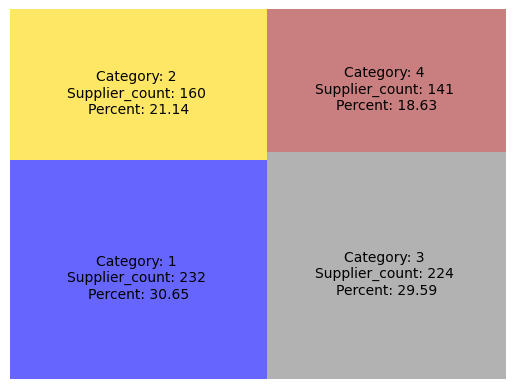

In [72]:
squarify.plot(sizes =final_report['Supplier'] ,
    color=['blue','gold','grey','brown'],
    label = ['\nCategory: {} \nSupplier_count: {} \nPercent: {:.2f}'.format(*final_rep.iloc[i]) for i in range(len(final_rep))],alpha = 0.6)
plt.axis('off')
plt.show()  